In [1]:
import numpy  as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("driver-data.csv")

In [3]:
df.head()

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25


In [4]:
df.shape

(4000, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [6]:
df.describe()

,id,mean_dist_day,mean_over_speed_perc
count,4.000000e+03,4000.000000,4000.000000
mean,3.423312e+09,76.041522,10.721000
std,1.154845e+03,53.469563,13.708543
min,3.423310e+09,15.520000,0.000000
25%,3.423311e+09,45.247500,4.000000
50%,3.423312e+09,53.330000,6.000000
75%,3.423313e+09,65.632500,9.000000
max,3.423314e+09,244.790000,100.000000


In [7]:
df.isna().sum()

id                      0
mean_dist_day           0
mean_over_speed_perc    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop('id',axis=1)

In [10]:
df.head()

,mean_dist_day,mean_over_speed_perc
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25


In [11]:
df.columns

Index(['mean_dist_day', 'mean_over_speed_perc'], dtype='object')

In [12]:
X = df[['mean_dist_day', 'mean_over_speed_perc']]

In [13]:
X.head()

,mean_dist_day,mean_over_speed_perc
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled[:5]

array([[-0.0898104 ,  1.26061251],
       [-0.43977285,  1.04174351],
       [-0.215131  ,  1.18765617],
       [-0.38066642,  0.8228745 ],
       [-0.40142849,  1.04174351]])

In [16]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

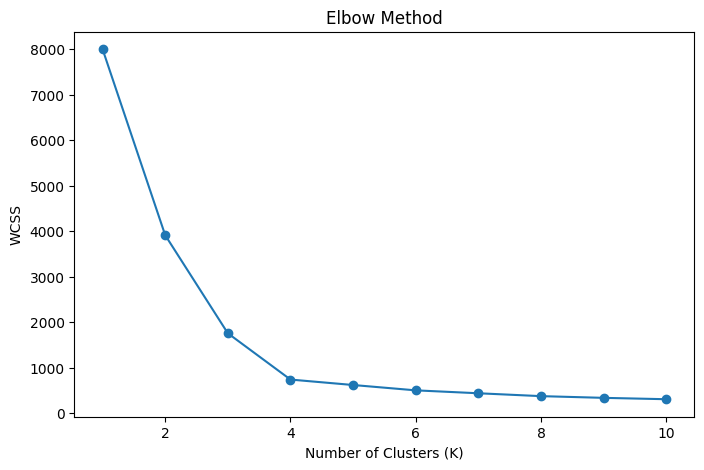

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X_scaled)

In [19]:
y_kmeans[:10]

array([2, 2, 2, 2, 2, 0, 2, 0, 2, 2], dtype=int32)

In [20]:
df['Cluster'] = y_kmeans

In [21]:
df.head()

,mean_dist_day,mean_over_speed_perc,Cluster
0,71.24,28,2
1,52.53,25,2
2,64.54,27,2
3,55.69,22,2
4,54.58,25,2


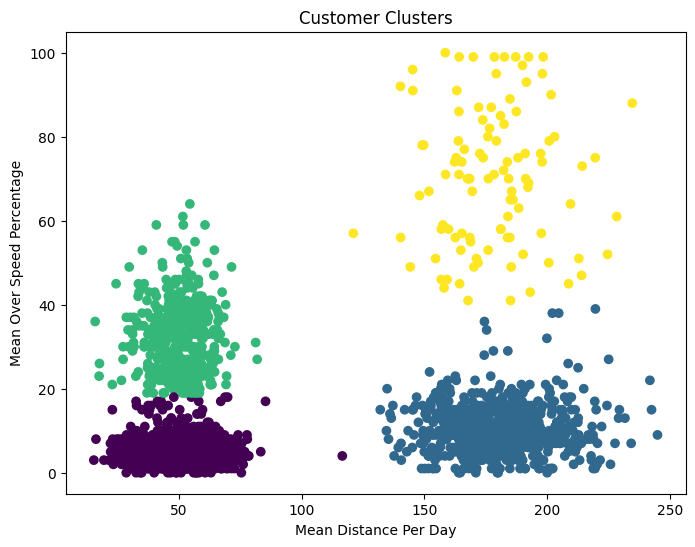

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['mean_dist_day'],
    df['mean_over_speed_perc'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Mean Distance Per Day')
plt.ylabel('Mean Over Speed Percentage')
plt.title('Customer Clusters')
plt.show()

In [23]:
kmeans.cluster_centers_

array([[-0.48678423, -0.40249736],
       [ 1.95263225, -0.0139714 ],
       [-0.47952334,  1.57909169],
       [ 1.90400473,  4.34582367]])

In [24]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['mean_dist_day', 'mean_over_speed_perc']
)

centroids

,mean_dist_day,mean_over_speed_perc
0,-0.486784,-0.402497
1,1.952632,-0.013971
2,-0.479523,1.579092
3,1.904005,4.345824


In [25]:
df['Cluster'].value_counts().sort_index()

Cluster
0    2774
1     695
2     427
3     104
Name: count, dtype: int64

In [26]:
df['Cluster'] = kmeans.labels_

cluster_mean = df.groupby('Cluster')[['mean_dist_day', 'mean_over_speed_perc']].mean()

cluster_mean

,mean_dist_day,mean_over_speed_perc
Cluster,,
0,50.016637,5.204037
1,180.434863,10.529496
2,50.404824,32.365340
3,177.835096,70.288462


In [27]:
df.head()

,mean_dist_day,mean_over_speed_perc,Cluster
0,71.24,28,2
1,52.53,25,2
2,64.54,27,2
3,55.69,22,2
4,54.58,25,2


In [28]:
df.groupby('Cluster')[['mean_dist_day', 'mean_over_speed_perc']].mean()

,mean_dist_day,mean_over_speed_perc
Cluster,,
0,50.016637,5.204037
1,180.434863,10.529496
2,50.404824,32.365340
3,177.835096,70.288462


In [29]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_original

array([[ 50.01663663,   5.20403749],
       [180.43486331,  10.5294964 ],
       [ 50.40482436,  32.36533958],
       [177.83509615,  70.28846154]])

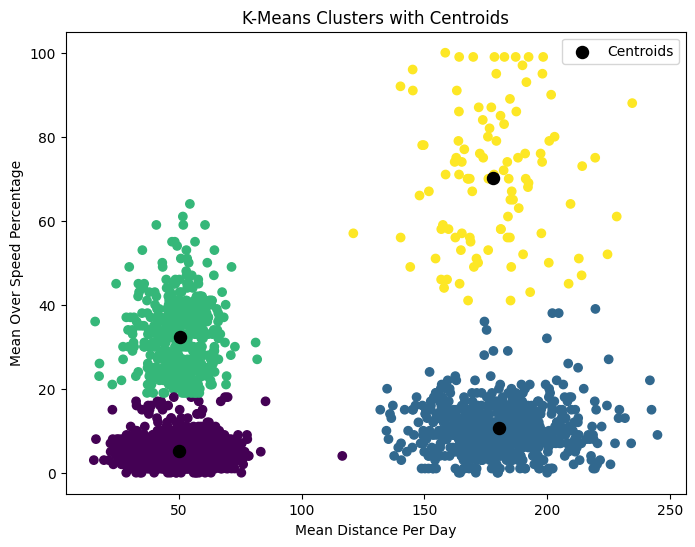

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['mean_dist_day'],
    df['mean_over_speed_perc'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker='o',
    s=75,
    color='black',
    label='Centroids'
)

plt.xlabel('Mean Distance Per Day')
plt.ylabel('Mean Over Speed Percentage')
plt.title('K-Means Clusters with Centroids')
plt.legend()
plt.show()

In [33]:
cluster_summary = df.groupby('Cluster').agg(
    avg_distance=('mean_dist_day', 'mean'),
    avg_speed=('mean_over_speed_perc', 'mean'),
    customer_count=('Cluster', 'count')
)

cluster_summary

,avg_distance,avg_speed,customer_count
Cluster,,,
0,50.016637,5.204037,2774
1,180.434863,10.529496,695
2,50.404824,32.365340,427
3,177.835096,70.288462,104
